***GATE Retention height***

APPENDIX — GATE HEIGHT SENSITIVITY TO ALLOWABLE OVERTOPPING DISCHARGE

  Design water level:       h_d     = NAP +4.50 m
  Significant wave height:  H_s,d   = 3.13 m
  Oblique wave factor:      γ_β     = 1.0
  Nose structure factor:    γ_η     = 1.0
  Sill level:               z_sill  = NAP -17.0 m
  Gravitational accel.:     g       = 9.81 m/s²

    q [m³/s/m] |  h_kr [m] |  h_r [m NAP] |  h_gate [m]
  ----------------------------------------------------
         0.001 |      8.06 |       +12.56 |       29.56
         0.010 |      5.65 |       +10.15 |       27.15
         0.100 |      3.25 |        +7.75 |       24.75
         0.200 |      2.53 |        +7.03 |       24.03
         0.500 |      1.57 |        +6.07 |       23.07
         1.000 |      0.85 |        +5.35 |       22.35 ◄ WOWK
         2.000 |      0.13 |        +4.63 |       21.63
         5.000 |     -0.83 |        +3.67 |       20.67
        10.000 |     -1.55 |        +2.95 |       19.95
        20.000 |     -2.28 | 

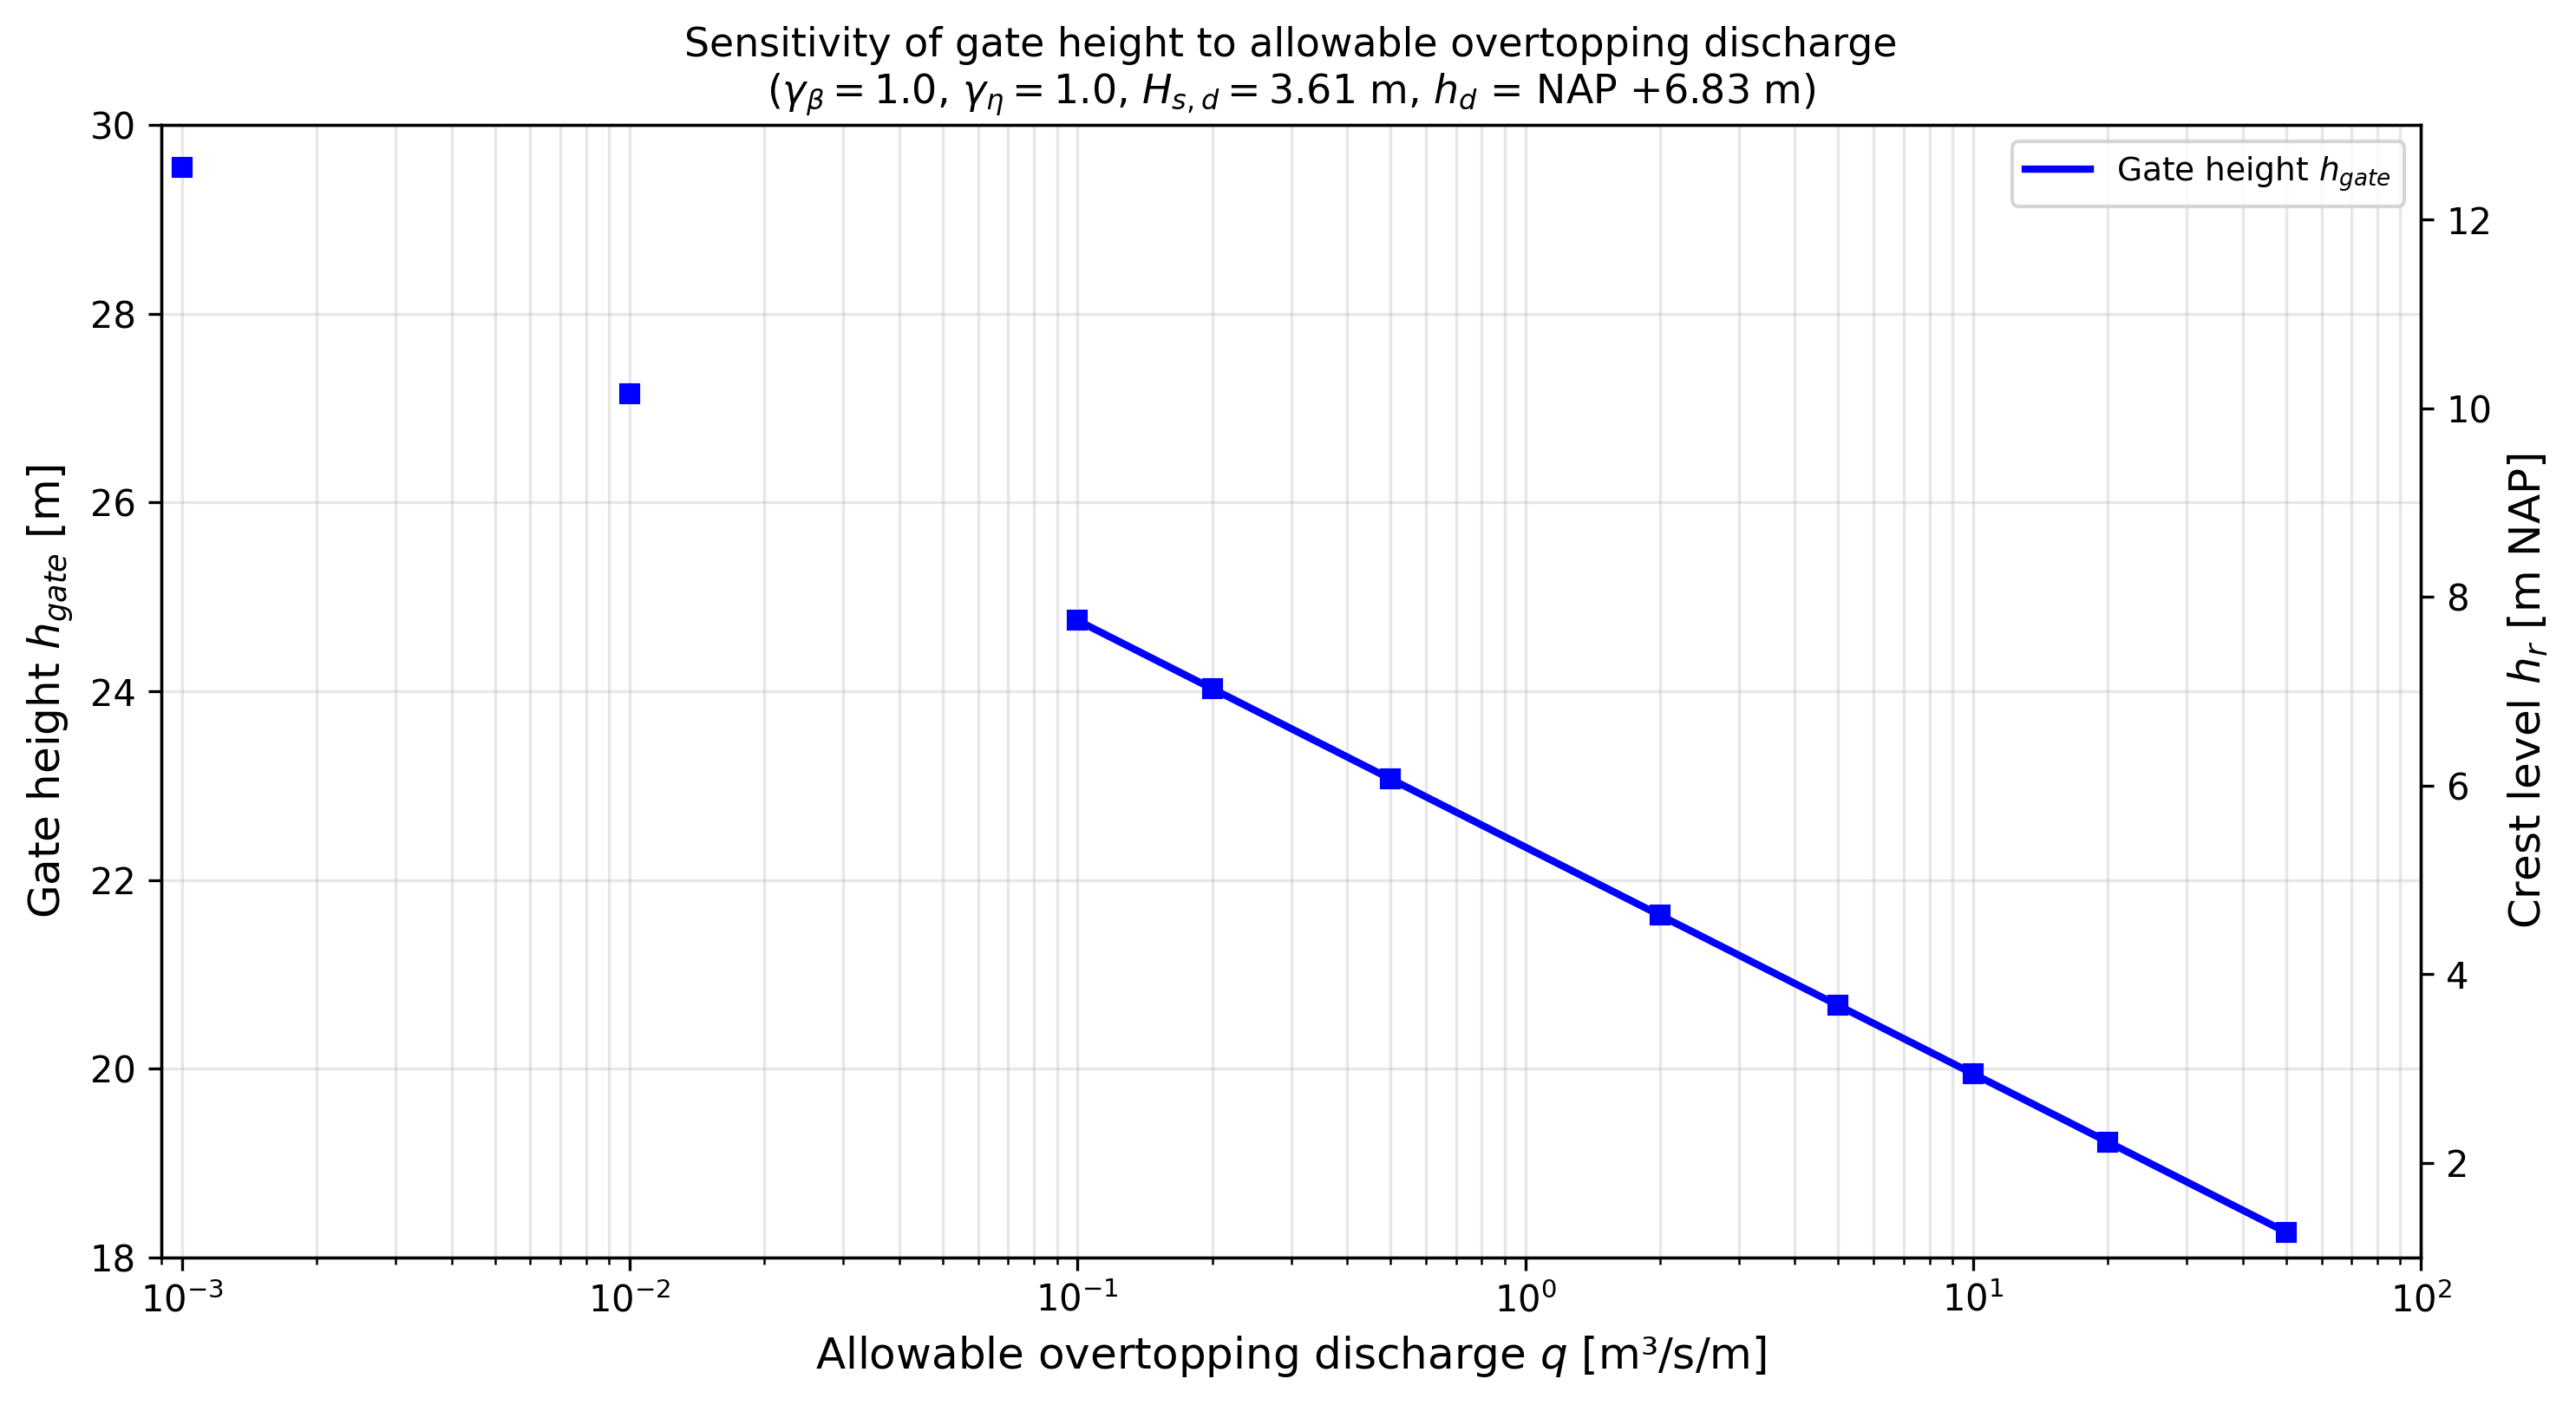

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# INPUT PARAMETERS
# ============================================================
h_d        = 4.5     # Design water level [m NAP]
H_s_d      = 3.13     # Design significant wave height [m]
g          = 9.81     # Gravitational acceleration [m/s²]
z_sill     = -17.0    # Sill level [m NAP]
gamma_beta = 1.0      # Normal wave incidence
gamma_eta  = 1.0      # No nose structure

denom = 0.13 * np.sqrt(g * H_s_d**3)

def calc_overtopping(q_val):
    h_kr = -(1/3) * gamma_beta * gamma_eta * H_s_d * np.log(q_val / denom)
    h_r = h_d + h_kr
    h_gate = h_r - z_sill
    return h_kr, h_r, h_gate

# ============================================================
# TABLE
# ============================================================
q_values = [ 0.001, 0.01, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]

print("=" * 80)
print("APPENDIX — GATE HEIGHT SENSITIVITY TO ALLOWABLE OVERTOPPING DISCHARGE")
print("=" * 80)
print()
print(f"  Design water level:       h_d     = NAP +{h_d:.2f} m")
print(f"  Significant wave height:  H_s,d   = {H_s_d:.2f} m")
print(f"  Oblique wave factor:      γ_β     = {gamma_beta:.1f}")
print(f"  Nose structure factor:    γ_η     = {gamma_eta:.1f}")
print(f"  Sill level:               z_sill  = NAP {z_sill:.1f} m")
print(f"  Gravitational accel.:     g       = {g:.2f} m/s²")
print()
print(f"  {'q [m³/s/m]':>12} | {'h_kr [m]':>9} | {'h_r [m NAP]':>12} | {'h_gate [m]':>11}")
print(f"  {'-' * 52}")

for qi in q_values:
    h_kr_i, h_r_i, h_gate_i = calc_overtopping(qi)
    marker = " ◄ WOWK" if qi == 1.0 else ""
    print(f"  {qi:>12.3f} | {h_kr_i:>9.2f} | {h_r_i:>+12.2f} | {h_gate_i:>11.2f}{marker}")

# ============================================================
# PLOT
# ============================================================
q_plot = np.logspace(-1, 1.7, 500)
h_kr_plot = -(1/3) * gamma_beta * gamma_eta * H_s_d * np.log(q_plot / denom)
h_r_plot = h_d + h_kr_plot
h_gate_plot = h_r_plot - z_sill

# q=1 point
h_kr_1, h_r_1, h_gate_1 = calc_overtopping(1.0)

fig, ax1 = plt.subplots(figsize=(10, 5.5), dpi=300)

# Main curve
ax1.plot(q_plot, h_gate_plot, 'b-', linewidth=2.0, label='Gate height $h_{gate}$')

# # q=1 highlight
# ax1.plot(1.0, h_gate_1, 'ro', markersize=10, zorder=5,
#          label=f'$q = 1$ m³/s/m (WOWK): $h_{{gate}}$ = {h_gate_1:.1f} m')



# # Annotation for q=1
# ax1.annotate(f'$q = 1$ m³/s/m\n$h_{{gate}}$ = {h_gate_1:.1f} m',
#              xy=(1.0, h_gate_1), xytext=(3.0, h_gate_1 + 1.5),
#              arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
#              fontsize=10, color='red', ha='left',
#              bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
#                        edgecolor='red', alpha=0.9))



# Discrete points
for qi in q_values:
    h_kr_i, h_r_i, h_gate_i = calc_overtopping(qi)
    if qi != 1.0:
        ax1.plot(qi, h_gate_i, 'bs', markersize=5, zorder=4)

ax1.set_xscale('log')
ax1.set_xlabel('Allowable overtopping discharge $q$ [m³/s/m]', fontsize=12)
ax1.set_ylabel('Gate height $h_{gate}$ [m]', fontsize=12)
ax1.set_title('Sensitivity of gate height to allowable overtopping discharge\n'
              r'($\gamma_\beta = 1.0$, $\gamma_\eta = 1.0$, $H_{s,d} = 3.61$ m, '
              r'$h_d$ = NAP +6.83 m)', fontsize=11)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, which='both', alpha=0.3)
ax1.set_xlim(0.0009, 100)
ax1.set_ylim(18, 30)

# Secondary y-axis: crest level
ax2 = ax1.twinx()
ax2.set_ylim(18 + z_sill, 30 + z_sill)
ax2.set_ylabel('Crest level $h_r$ [m NAP]', fontsize=12)

plt.tight_layout()
plt.savefig("gate_height_sensitivity_q.png", dpi=300, bbox_inches='tight')
plt.show()

***Vessel calculation***

In [11]:
import pandas as pd

# --- DHMR parameters for Nieuwe Waterweg (raai 1030–1025) ---
ALAT = -0.90        # [m NAP]
HMT  =  0.30        # [m] hydro-meteorological allowance
FWA_pct = 0.01       # [-] fresh water allowance (1% of draft)
UKC_pct = 0.10       # [-] gross UKC seagoing, sailing (10% of draft)
sill_level = -17.0   # [m NAP] sill level Holland Barrier

# --- Vessel classes: (name, max draft [m]) ---
vessels = [
    ("New Panamax",     15.00),
    ("Aframax Tanker",  13.40),
    ("Panamax",         12.00),
    ("Handymax",        11.50),
]

# --- Compute NGD for each vessel ---
results = []
for name, T in vessels:
    FWA = FWA_pct * T
    UKC = UKC_pct * T
    NGD = -T - FWA - UKC + ALAT - HMT
    passes = abs(NGD) <= abs(sill_level)
    results.append({
        "Vessel class": name,
        "T [m]": T,
        # "FWA [m]": round(FWA, 2),
        # "UKC [m]": round(UKC, 2),
        "NGD [m NAP]": round(NGD, 2),
        "|NGD| ≤ 17.0": "✓" if passes else "✗",
    })

df = pd.DataFrame(results)
print(df.to_string(index=False))

  Vessel class  T [m]  NGD [m NAP] |NGD| ≤ 17.0
   New Panamax   15.0       -17.85            ✗
Aframax Tanker   13.4       -16.07            ✓
       Panamax   12.0       -14.52            ✓
      Handymax   11.5       -13.97            ✓


T  = 37037 year
f  = 2.70e-05
WL = 5.35 m + NAP
Hs = 3.43 m
Tf = 12.01 s
